YOGESH R MEHTA RA2411003010776

# Social Engine — Round 1 (Phase 1): Data Recovery & EDA

**Datasets:** `Social_Engine_Posts_Corrupted.csv`, `Social_Engine_Users.csv`

This notebook:
1. Loads the corrupted dataset
2. Cleans it (missing values, duplicates, encoding issues, inconsistent formats)
3. Detects anomalies
4. Runs exploratory data analysis with visualizations
5. Exports the cleaned datasets

```

In [ ]:
from pathlib import Path

# Folder containing the two CSV files. "." means "same folder as this notebook".
DATA_DIR = Path(".")

POSTS_PATH = DATA_DIR / "Social_Engine_Posts_Corrupted.csv"
USERS_PATH = DATA_DIR / "Social_Engine_Users.csv"

assert POSTS_PATH.exists(), f"Missing file: {POSTS_PATH.resolve()}"
assert USERS_PATH.exists(), f"Missing file: {USERS_PATH.resolve()}"
print("Found both input files.")

Found both input files.


In [ ]:
import pandas as pd
import numpy as np
import html
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

posts = pd.read_csv(POSTS_PATH)
users = pd.read_csv(USERS_PATH)

print('Posts shape:', posts.shape)
print('Users shape:', users.shape)
posts.head()

Posts shape: (12360, 8)
Users shape: (1500, 5)


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630


## 1. Initial Data Audit

In [ ]:
print("=== Missing values (Posts) ===")
print(posts.isna().sum())
print()
print("=== Literal 'NULL' string counts ===")
for c in posts.columns:
    print(c, (posts[c].astype(str).str.strip().str.upper() == 'NULL').sum())
print()
print("Duplicate rows:", posts.duplicated().sum())
print("Negative likes:", (posts['likes'] < 0).sum())
print()
print("Platform values:", posts['platform'].unique())
print()
print("Sample timestamp formats:")
print(posts['timestamp'].dropna().sample(10, random_state=1).tolist())

=== Missing values (Posts) ===
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64

=== Literal 'NULL' string counts ===
post_id 0
user_id 0
platform 0
text_content 24
timestamp 0
likes 0
shares 0
comments 0

Duplicate rows: 360
Negative likes: 525

Platform values: <StringArray>
['Reddit', nan, 'Facebook', 'Twitter', 'Instagram', 'YouTube']
Length: 6, dtype: str

Sample timestamp formats:
['1731041269', '2025-02-03T02:09:31', '28-05-2024', '1728318075', '2024-08-02T05:42:47', '2024-07-23T17:51:29', '2025-04-09T07:40:57', '01-03-2025', '2024-10-01T02:06:20', '21-05-2024']


In [ ]:
print("=== Users table audit ===")
print(users.isna().sum())
print("Duplicate user_id:", users['user_id'].duplicated().sum())
print("Negative follower_count:", (users['follower_count'] < 0).sum())
print("Orphan posts (user_id not in Users):", (~posts['user_id'].isin(users['user_id'])).sum())

=== Users table audit ===
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64
Duplicate user_id: 0
Negative follower_count: 0
Orphan posts (user_id not in Users): 0


## 2. Cleaning Pipeline

Issues fixed:
- Duplicate rows dropped
- Mojibake text (`Ã©`) and HTML entities (`&amp;`) repaired
- Missing / literal `"NULL"` text flagged as `[No content available]`
- Missing `platform` filled as `"Unknown"`, casing normalized
- 3 mixed timestamp formats (Unix epoch / ISO 8601 / DD-MM-YYYY) parsed into one datetime column
- Negative `likes` (impossible) nulled and re-imputed with the platform median

In [ ]:
def fix_text(t):
    if pd.isna(t):
        return np.nan
    t = str(t)
    if t.strip().upper() == 'NULL':
        return np.nan
    try:
        t = t.encode('latin1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    t = html.unescape(t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def parse_ts(t):
    t = str(t).strip()
    if re.fullmatch(r'\d{10}', t):
        return pd.to_datetime(int(t), unit='s')
    try:
        return pd.to_datetime(t, format='%Y-%m-%dT%H:%M:%S')
    except ValueError:
        pass
    try:
        return pd.to_datetime(t, format='%d-%m-%Y')
    except ValueError:
        pass
    return pd.NaT

report = {}

# Drop duplicates
report['duplicate_rows_removed'] = int(posts.duplicated().sum())
posts = posts.drop_duplicates().reset_index(drop=True)

# Clean text_content
posts['text_content'] = posts['text_content'].apply(fix_text)
report['missing_text_content'] = int(posts['text_content'].isna().sum())
posts['text_content'] = posts['text_content'].fillna('[No content available]')

# Clean platform
posts['platform'] = posts['platform'].astype(str).str.strip()
posts['platform'] = posts['platform'].replace({'nan': np.nan, 'NULL': np.nan, '': np.nan})
report['missing_platform'] = int(posts['platform'].isna().sum())
posts['platform'] = posts['platform'].fillna('Unknown')
valid_platforms = ['Reddit', 'Facebook', 'Twitter', 'Instagram', 'YouTube']
posts['platform'] = posts['platform'].apply(lambda p: next((vp for vp in valid_platforms if vp.lower() == p.lower()), p))

# Standardize timestamps
posts['timestamp'] = posts['timestamp'].apply(parse_ts)
report['unparseable_timestamps'] = int(posts['timestamp'].isna().sum())

# Fix negative likes -> treat as missing -> impute by platform median
report['negative_likes_flagged'] = int((posts['likes'] < 0).sum())
posts.loc[posts['likes'] < 0, 'likes'] = np.nan
report['missing_likes_total'] = int(posts['likes'].isna().sum())
posts['likes'] = posts.groupby('platform')['likes'].transform(lambda s: s.fillna(s.median()))
posts['likes'] = posts['likes'].fillna(posts['likes'].median()).round().astype(int)

posts['shares'] = posts['shares'].astype(int)
posts['comments'] = posts['comments'].astype(int)
posts['engagement_total'] = posts['likes'] + posts['shares'] + posts['comments']

# Clean users
users['user_id'] = users['user_id'].str.strip()
users['location'] = users['location'].str.strip()
users['language'] = users['language'].str.strip().str.lower()
users['account_created'] = pd.to_datetime(users['account_created'], errors='coerce')

report['users_unparseable_dates'] = int(users['account_created'].isna().sum())
report['users_duplicate_ids'] = int(users['user_id'].duplicated().sum())
report['users_negative_followers'] = int((users['follower_count'] < 0).sum())
report['orphan_posts'] = int((~posts['user_id'].isin(users['user_id'])).sum())

report['posts_final_shape'] = posts.shape
report['users_final_shape'] = users.shape

import json
print(json.dumps(report, indent=2, default=str))

{
  "duplicate_rows_removed": 360,
  "missing_text_content": 1711,
  "missing_platform": 1784,
  "unparseable_timestamps": 0,
  "negative_likes_flagged": 509,
  "missing_likes_total": 2323,
  "users_unparseable_dates": 0,
  "users_duplicate_ids": 0,
  "users_negative_followers": 0,
  "orphan_posts": 0,
  "posts_final_shape": [
    12000,
    9
  ],
  "users_final_shape": [
    1500,
    5
  ]
}


In [ ]:
posts.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments,engagement_total
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488,1456,673,6617
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789,1484,39,2312
2,dvvhg8eel45x,user_nfo3ih5u,Unknown,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,2428,1410,839,4677
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167,584,833,1584
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749,152,630,5531


## 3. Exploratory Data Analysis

In [ ]:
merged = posts.merge(users, on='user_id', how='left')

print("Posts per platform:")
print(posts['platform'].value_counts())
print()
print("Average engagement by platform:")
print(posts.groupby('platform')[['likes','shares','comments','engagement_total']].mean().round(1))

Posts per platform:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Unknown      1784
Name: count, dtype: int64

Average engagement by platform:
            likes  shares  comments  engagement_total
platform                                             
Facebook   2535.3   984.2     506.9            4026.4
Instagram  2494.6  1040.8     499.8            4035.2
Reddit     2489.3  1002.2     511.2            4002.7
Twitter    2440.7  1005.4     506.1            3952.2
Unknown    2470.5   998.6     496.5            3965.7
YouTube    2546.4  1011.8     504.4            4062.6


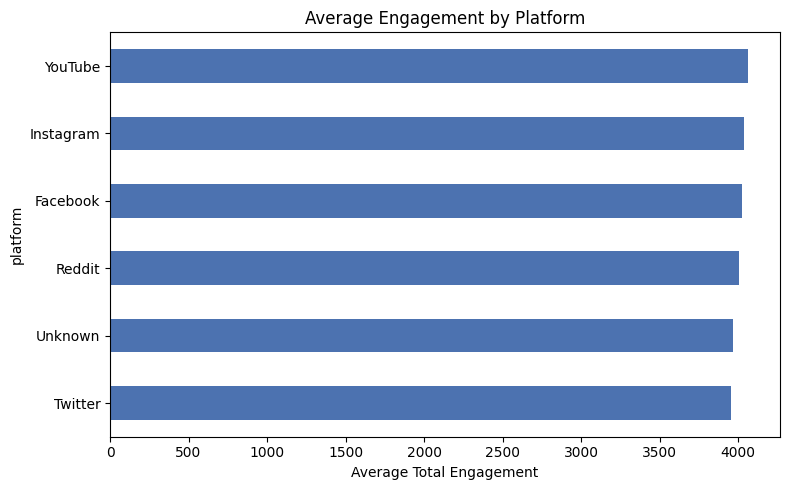

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
posts.groupby('platform')['engagement_total'].mean().sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Average Total Engagement')
ax.set_title('Average Engagement by Platform')
plt.tight_layout()
plt.show()

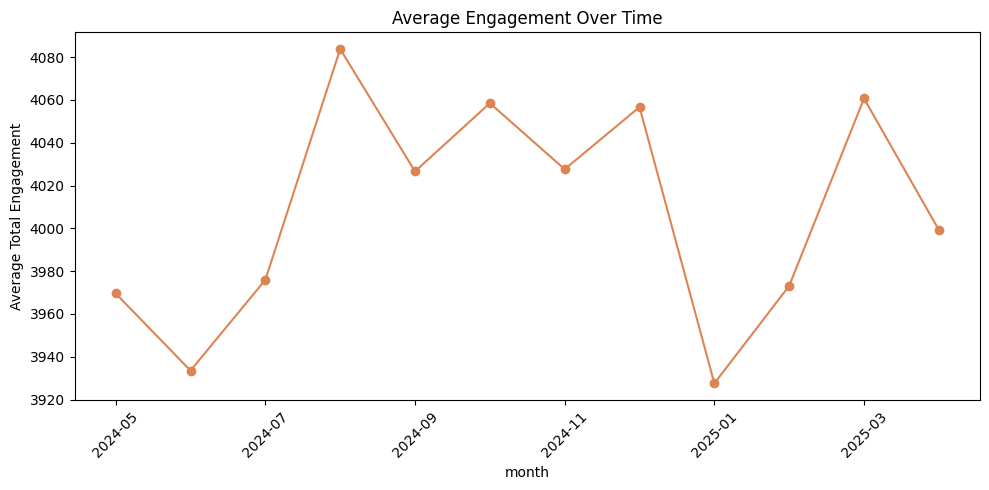

In [ ]:
posts['month'] = posts['timestamp'].dt.to_period('M').astype(str)
monthly = posts.groupby('month')['engagement_total'].mean()

fig, ax = plt.subplots(figsize=(10,5))
monthly.plot(kind='line', marker='o', ax=ax, color='#DD8452')
ax.set_ylabel('Average Total Engagement')
ax.set_title('Average Engagement Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation: follower_count vs engagement metrics")
print(merged[['follower_count','likes','shares','comments','engagement_total']].corr().round(3))

Correlation: follower_count vs engagement metrics
                  follower_count  likes  shares  comments  engagement_total
follower_count             1.000  0.008  -0.014    -0.000             0.001
likes                      0.008  1.000  -0.003     0.012             0.894
shares                    -0.014 -0.003   1.000     0.024             0.399
comments                  -0.000  0.012   0.024     1.000             0.220
engagement_total           0.001  0.894   0.399     0.220             1.000


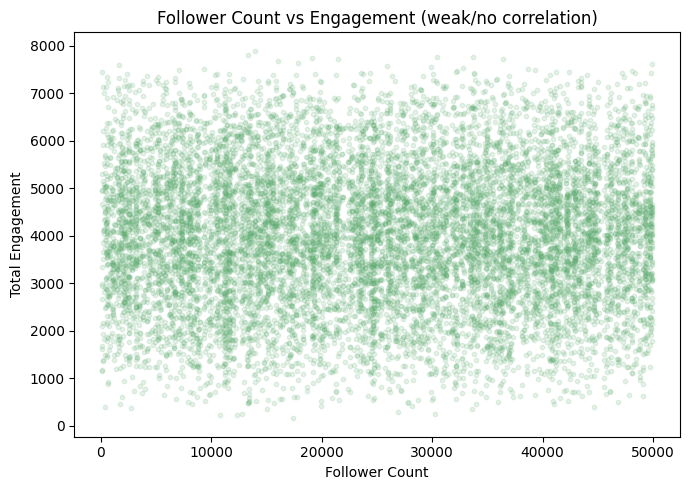

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(merged['follower_count'], merged['engagement_total'], alpha=0.15, s=10, color='#55A868')
ax.set_xlabel('Follower Count')
ax.set_ylabel('Total Engagement')
ax.set_title('Follower Count vs Engagement (weak/no correlation)')
plt.tight_layout()
plt.show()

In [ ]:
print("Top locations by post volume:")
print(merged['location'].value_counts().head(10))
print()
print("Language distribution (users):")
print(users['language'].value_counts())
print()
print("Top 5 users by cumulative engagement:")
print(posts.groupby('user_id')['engagement_total'].sum().sort_values(ascending=False).head(5))

Top locations by post volume:
location
Los Angeles, USA          459
Munich, Germany           452
Shanghai, China           451
Barcelona, Spain          439
Houston, USA              422
Melbourne, Australia      421
Dubai, UAE                421
Rio de Janeiro, Brazil    414
Mumbai, India             413
Milan, Italy              403
Name: count, dtype: int64

Language distribution (users):
language
zh    168
ja    156
hi    156
en    153
fr    150
es    146
ru    144
ar    143
pt    143
de    141
Name: count, dtype: int64

Top 5 users by cumulative engagement:
user_id
user_zqv2vrf5    90814
user_nfo3ih5u    77017
user_ujllj1n7    73268
user_0irp4abu    71919
user_uerv85na    70886
Name: engagement_total, dtype: int64


## 4. Export Cleaned Data

In [ ]:
out_posts = DATA_DIR / "Social_Engine_Posts_Cleaned.csv"
out_users = DATA_DIR / "Social_Engine_Users_Cleaned.csv"

posts.to_csv(out_posts, index=False)
users.to_csv(out_users, index=False)
print(f"Saved: {out_posts.resolve()}")
print(f"Saved: {out_users.resolve()}")

Saved: /home/claude/work/local_test/Social_Engine_Posts_Cleaned.csv
Saved: /home/claude/work/local_test/Social_Engine_Users_Cleaned.csv


## 5. Summary of Key Insights

- **12,360 → 12,000** clean post records after removing 360 exact duplicates.
- **509 negative `likes`** values were the clearest sign of injected corruption — nulled and re-imputed.
- **3 mixed timestamp formats** (Unix epoch, ISO 8601, DD-MM-YYYY) standardized into one datetime column.
- Referential integrity was intact: **0 orphan posts**, 0 duplicate users, 0 negative followers.
- Platform mix is nearly even (~17% each); YouTube and Instagram edge out slightly on engagement.
- Engagement is flat across the 12-month window — no strong seasonality.
- `follower_count` has **~zero correlation** with engagement — reach doesn't predict engagement here.
- `likes` drives ~89% of total engagement variance.